In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [2]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS=3
EPOCHS=50


In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
'PlantVillage', shuffle = True, image_size = (IMAGE_SIZE, IMAGE_SIZE), batch_size= BATCH_SIZE

)

Found 2152 files belonging to 3 classes.


In [4]:
class_name = dataset.class_names
class_name


['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [5]:
len(dataset)

68

In [6]:
for image_batch, label_batch in dataset.take(1):
 print(image_batch.shape)
 print(label_batch.numpy())

(32, 256, 256, 3)
[0 1 1 1 1 1 0 0 1 1 1 0 1 0 0 0 2 1 0 0 0 0 0 1 0 0 1 1 2 0 1 1]


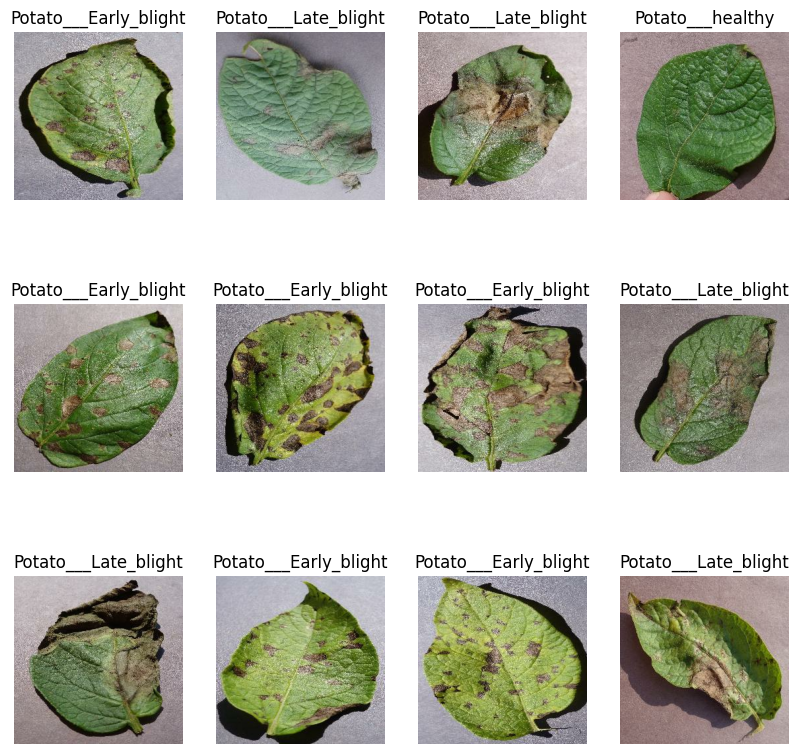

In [7]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in dataset.take(1):
    for i in range (12):
        ax= plt.subplot(3,4, i+1)
        plt.imshow(image_batch[i].numpy().astype('uint8'))
        plt.title(class_name[label_batch[i]])
        plt.axis('off')

In [8]:
train_size = 0.8
len(dataset)*train_size


54.400000000000006

In [9]:
train_ds = dataset.take(54)
len(train_ds)

54

In [10]:
test_ds = dataset.skip(54)

In [11]:
len(test_ds)

14

In [12]:
val_size = 0.1
len(dataset)*val_size

6.800000000000001

In [13]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [14]:
def get_dataset_partitations_tf( ds, train_split = 0.8, val_split = 0.1, test_split = 0.1, shuffle = True, shuffle_size = 10000):
    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed = 12)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [15]:
train_ds, val_ds, test_ds = get_dataset_partitations_tf(dataset)

In [16]:
len(train_ds)

54

In [17]:
len(val_ds)


6

In [18]:
len(test_ds)

8

In [19]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [20]:
resize_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

In [21]:
data_augmentation = tf.keras.Sequential({
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2)
})

In [22]:


input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = models.Sequential([
    resize_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)



C:\Users\Deepak\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (32, 254, 254, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (32, 127, 127, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (32, 125, 125, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (32, 62, 62, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (32, 60, 60, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (32, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (32, 28, 28, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (32, 14, 14, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (32, 12, 12, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (32, 6, 6, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (32, 4, 4, 64)              │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (32, 2, 2, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (32, 256)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 64)                    │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 3)                     │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
optimizer = 'adam',
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits= False),
metrics = ['accuracy']

)

In [25]:
history = model.fit(

train_ds, epochs= EPOCHS, batch_size= BATCH_SIZE, verbose =1, validation_data = val_ds
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 65s 974ms/step - accuracy: 0.4624 - loss: 0.9137 - val_accuracy: 0.4375 - val_loss: 0.9198
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 45s 836ms/step - accuracy: 0.5463 - loss: 0.8238 - val_accuracy: 0.6719 - val_loss: 0.6843
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 46s 854ms/step - accuracy: 0.7575 - loss: 0.5571 - val_accuracy: 0.7812 - val_loss: 0.4710
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 46s 849ms/step - accuracy: 0.8258 - loss: 0.4184 - val_accuracy: 0.8594 - val_loss: 0.3318
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 44s 815ms/step - accuracy: 0.8663 - loss: 0.3468 - val_accuracy: 0.8802 - val_loss: 0.2732
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 699ms/step - accuracy: 0.9080 - loss: 0.2519 - val_accuracy: 0.9531 - val_loss: 0.1427
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 696ms/step - accuracy: 0.9462 - loss: 0.1469 - val_accuracy: 0.8854 - val_loss: 0.3463
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 37s 690ms/step - accuracy: 0.8385 - loss: 0.4774 - val_accu

In [26]:
history.history['accuracy']

[0.46238425374031067,
 0.5462962985038757,
 0.7575231194496155,
 0.8258101940155029,
 0.8663194179534912,
 0.9079861044883728,
 0.9461805820465088,
 0.8385416865348816,
 0.9241898059844971,
 0.9658564925193787,
 0.9710648059844971,
 0.9722222089767456,
 0.9866898059844971,
 0.9733796119689941,
 0.9814814925193787,
 0.9809027910232544,
 0.9936342835426331,
 0.9849537014961243,
 0.9276620149612427,
 0.9918981194496155,
 0.9913194179534912,
 0.9918981194496155,
 0.9988425970077515,
 0.9918981194496155,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

In [28]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

Text(0.5, 1.0, 'Training & Validation Loss')

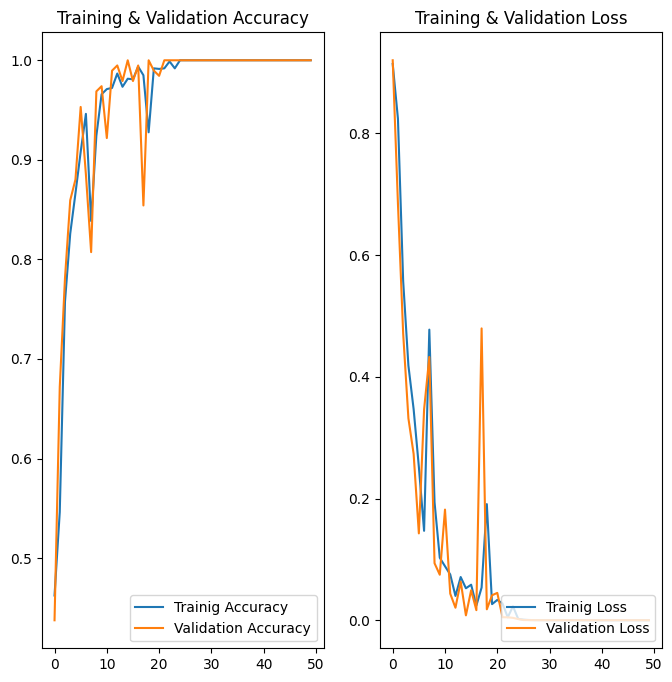

In [32]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label= 'Trainig Accuracy')
plt.plot(range(EPOCHS), val_acc, label= 'Validation Accuracy')
plt.legend(loc = 'lower right')
plt.title("Training & Validation Accuracy")

plt.subplot(1,2,2)
plt.plot(range(EPOCHS), loss, label= 'Trainig Loss')
plt.plot(range(EPOCHS), val_loss, label= 'Validation Loss')
plt.legend(loc = 'lower right')
plt.title("Training & Validation Loss")


First image to predict:
actual label:  Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
predicted label:  Potato___Early_blight


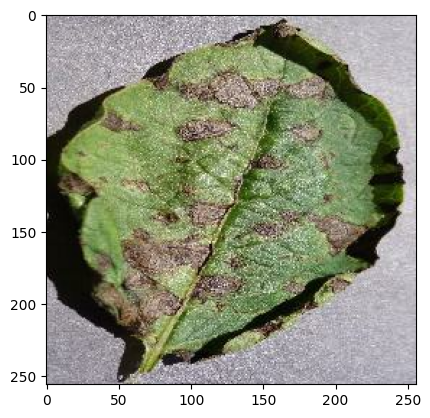

In [38]:
import numpy as np

for image_batch, label_batch in test_ds.take(1):
 first_image = image_batch[0].numpy().astype('uint8')
 first_label = label_batch[0].numpy()

 print('First image to predict:')
 plt.imshow(first_image)
 print('actual label: ', class_name[first_label])

 batch_prediction = model.predict(image_batch)
 print ('predicted label: ', class_name[np.argmax(batch_prediction[0])])

In [42]:
def predict (model, img):
 img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
 img_array = tf.expand_dims(img_array, 0)

 predictions = model.predict(img_array)

 predicted_class = class_name[np.argmax(predictions[0])]
 confidence = round(100 * (np.max(predictions[0])), 2)
 return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


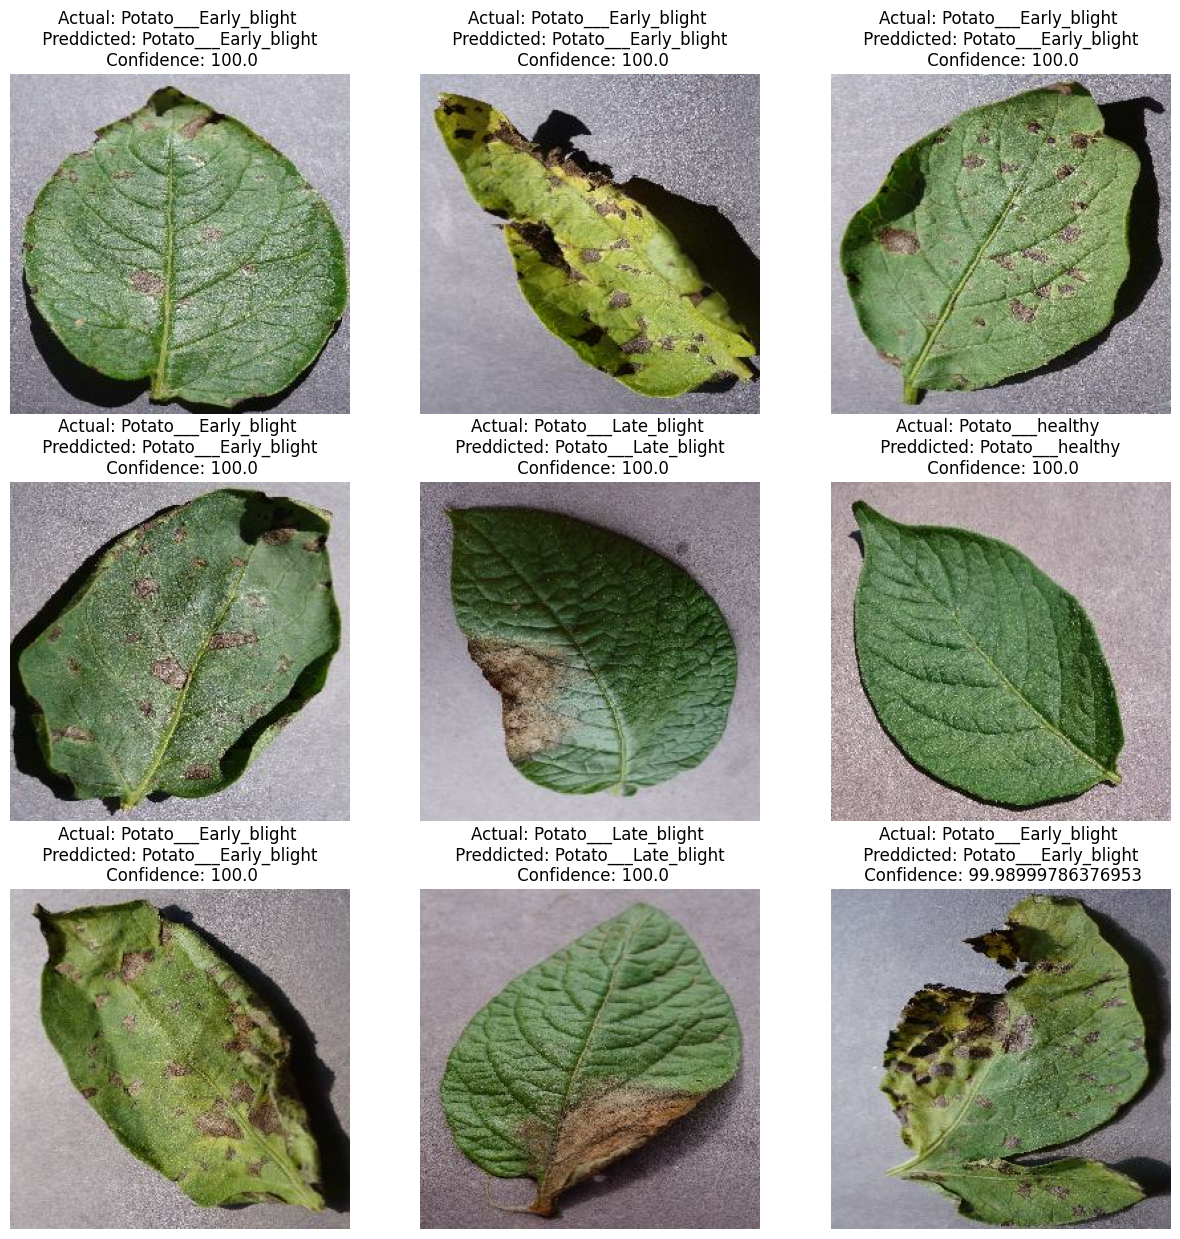

In [46]:
plt.figure(figsize=(15,15))
for images, labels in test_ds.take(1):
 for i in range (9):
  ax = plt.subplot(3,3,i+1)
  plt.imshow(images[i].numpy().astype('uint8'))
  predicted_class, confidence = predict(model, images[i].numpy())
  actual_class = class_name[labels[i]]

  plt.title(f'Actual: {actual_class} \n Preddicted: {predicted_class} \n Confidence: {confidence}')
  plt.axis('off')

In [50]:
model_version = 1
model.save(f"../models/{model_version}.keras")
